In [1]:
# Imports
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.animation as animation
import cv2
from tqdm import tqdm

In [2]:
# Open an image file (we will overlay points on this video, not the image)
tmapPath = r'C:\Users\awebb\Documents\Programming\Python\MANTIS\training_data\unprocessed_training_data\hello\sample_1.png'
loadedTmapImage = Image.open(tmapPath)

# Convert the image to a numpy array (not directly used in the video but kept)
loadedTmapArray = np.array(loadedTmapImage)

In [3]:
# Horizontal transformation
def horizontal_transform(points, distance):
    return [[x + distance, y] for x, y in points]

In [4]:
# Vertical transformation
def vertical_transform(points, distance):
    return [[x, y + distance] for x, y in points]

In [5]:
# Rotational transformation
def rotate_points(points, angleDegrees, centerPointIndex):
    """
    Rotate a set of points around a specified center point.
    
    Parameters:
    - points: List of [x, y] coordinates.
    - angle_degrees: The angle to rotate the points (in degrees).
    - center_point: The point [cx, cy] around which to rotate.
    
    Returns:
    - List of rotated points.
    """
    # FILL ME IN
    angleRadians = np.radians(angleDegrees)
    # cx, cy = points[centerPointIndex]  # Center of rotation
    cx, cy = 255*0.5, 255*0.5

    # Perform the rotation
    rotated_points = []
    for i, (x, y) in enumerate(points):
        # if i < len(points)/2:
        # cx, cy = points[centerPointIndex] 
        # else:
        #     cx, cy = points[centerPointIndex]
        new_x = cx + np.cos(angleRadians) * (x - cx) - np.sin(angleRadians) * (y - cy)
        new_y = cy + np.sin(angleRadians) * (x - cx) + np.cos(angleRadians) * (y - cy)
        rotated_points.append([new_x, new_y])

    return rotated_points

In [6]:
# Scale transformation
def scale_points(points, scale):
    """
    Scale a set of points around the origin.
    
    Parameters:
    - points: List of [x, y] coordinates.
    - scale: The scale factor.
    
    Returns:
    - List of scaled points.
    """
    # FILL ME IN
    return [[x * scale, y * scale] for x, y in points]

In [7]:
# Shear transformation
def shear_points(points, shearX, shearY):
    """
    Shear a set of points.
    
    Parameters:
    - points: List of [x, y] coordinates.
    - shearX: The shear factor in the x direction.
    - shearY: The shear factor in the y direction.
    
    Returns:
    - List of sheared points.
    """
    # FILL ME IN
    sheared_points = []
    for x, y in points:
        new_x = x + shearX * y
        new_y = y + shearY * x
        sheared_points.append([new_x, new_y])
    
    return sheared_points

In [8]:
# Animation function
def create_multiple_hand_animations(image_arrays, interval=1/30):
    """
    Function to create multiple animations based on a list of image arrays and hand connections.

    Parameters:
    - image_arrays: List of numpy arrays of the images to process.
    - interval: Time interval between frames (in seconds).

    Returns:
    - None. Displays multiple animations using matplotlib.
    """

    # Set up the figure and axes for each image_array
    num_images = len(image_arrays)
    fig, axes = plt.subplots(1, num_images, figsize=(5*num_images, 5))

    # Preprocess the image arrays to extract the x and y coordinates for each one
    hand_connections = [
        (0, 1), (1, 2), (2, 3), (3, 4),        # Thumb
        (0, 5), (5, 6), (6, 7), (7, 8),        # Index Finger
        (0, 9), (9, 10), (10, 11), (11, 12),   # Middle Finger
        (0, 13), (13, 14), (14, 15), (15, 16), # Ring Finger
        (0, 17), (17, 18), (18, 19), (19, 20), # Pinky Finger
        (5, 9), (9, 13), (13, 17)              # Palm
    ]

    data = []
    for image_array in image_arrays:
        half = int(len(image_array[0]) / 2) * 0
        x = image_array[:, :, 0]
        y = image_array[:, :, 1]
        data.append((x, y))  # Append each x, y pair to data

    # Update function for the animation
    def update(num):
        for i, ax in enumerate(axes):
            ax.cla()  # Clear the axis
            ax.set_xlim(0, 255)
            ax.set_ylim(0, 255)
            ax.set_title(f'Frame {num}')
            
            x, y = data[i]
            
            # Scatter plot for the points (landmarks)
            ax.scatter(x[num], y[num], c='red')  # Plot the landmarks in red

            # Draw the connections between landmarks
            for connection in hand_connections:
                # Get the coordinates of the connected points
                start_idx, end_idx = connection
                ax.plot([x[num][start_idx], x[num][end_idx]], 
                        [y[num][start_idx], y[num][end_idx]], 
                        'blue')  # Draw the connections in blue

    # Create the animation
    ani = animation.FuncAnimation(fig, update, frames=(list(range(len(data[0][0]) - 1))), interval=interval)

    # Display the animation
    plt.show()

In [9]:
# Restore the blue channel
def restore_blue_channel(generated_tmap, original_tmap, display=False):
    
    # Copy the generated tmap to avoid modifying the original data
    old_tmap = np.copy(generated_tmap)
    
    # Restore the blue channel (channel index 2 in RGB)
    new_channel = original_tmap[:, :, 2]
    restored_tmap = np.dstack((old_tmap, new_channel))

    if display:
        # Plot the old tmap, the new channel, and teh restored tmap
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(np.dstack((old_tmap, np.zeros_like(old_tmap[:, :, 0]))))
        axes[0].set_title("Original Tmap")
        axes[1].imshow(new_channel, cmap='gray')
        axes[1].set_title("New Channel")
        axes[2].imshow(restored_tmap)
        axes[2].set_title("Restored Tmap")
        plt.show()

    return restored_tmap

In [10]:
# Apply all transformations to the points, creating a new set of points for each transformation
loadedTmapWithoutBlue = np.array([[(landmark[0], landmark[1]) for landmark in frame] for frame in loadedTmapArray])

In [11]:
# Create the ranges that we will use for the transformations
xRange = range(-10, 10, 10)
yRange = range(-10, 10, 5)
rotationRange = range(-12, 12)
scaleRange = np.linspace(0.1, 2, 10)
shearRange = [(x, y) for x in np.linspace(-0.2, 0.2, 10) for y in np.linspace(-0.2, 0.2, 10)]

generatedTmaps = []

In [12]:
# Generate horizontal tmaps
# generate and save every possible tmap with the ranges provided
print("Generating Tmaps...")
print("Horizontal Transformations")
for x in xRange:
    horizontalTmap = np.array([horizontal_transform(frame, x) for frame in loadedTmapWithoutBlue])
    generatedTmaps.append(horizontalTmap)

Generating Tmaps...
Horizontal Transformations


In [13]:
print("Vertical Transformations")
for y in yRange:
    verticalTmap = np.array([vertical_transform(frame, y) for frame in loadedTmapWithoutBlue])
    generatedTmaps.append(verticalTmap)

Vertical Transformations


In [ ]:
print("Rotational Transformations")
for angle in rotationRange:
    rotatedTmap = np.array([rotate_points(frame, angle, 9) for frame in loadedTmapWithoutBlue])
    generatedTmaps.append(rotatedTmap)

In [ ]:
print("Scaling Transformations")
for scale in scaleRange:
    scaledTmap = np.array([scale_points(frame, scale) for frame in loadedTmapWithoutBlue])
    generatedTmaps.append(scaledTmap)

In [ ]:
print("Shearing Transformations")
for shear in shearRange:
    shearedTmap = np.array([shear_points(frame, shear[0], shear[1]) for frame in loadedTmapWithoutBlue])
    generatedTmaps.append(shearedTmap)

In [14]:
totalFrames = sum(len(tmap) for tmap in generatedTmaps)
with tqdm(total=totalFrames, desc="Saving Tmaps") as pbar:
    for i, tmap in enumerate(generatedTmaps):
        fullTmap = restore_blue_channel(tmap, loadedTmapArray)
        fullTmapImage = Image.fromarray(fullTmap.astype('uint8'))
        fullTmapImage.save(fr"C:\Users\awebb\Documents\Programming\Python\MANTIS\src\DataAugmentation\generatedTmaps\generated_tmap_{i}.png")

        pbar.update(len(loadedTmapWithoutBlue))

Saving Tmaps: 100%|██████████| 2584/2584 [00:00<00:00, 95517.48it/s]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-10..214].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5..219].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-10..224].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5..224].


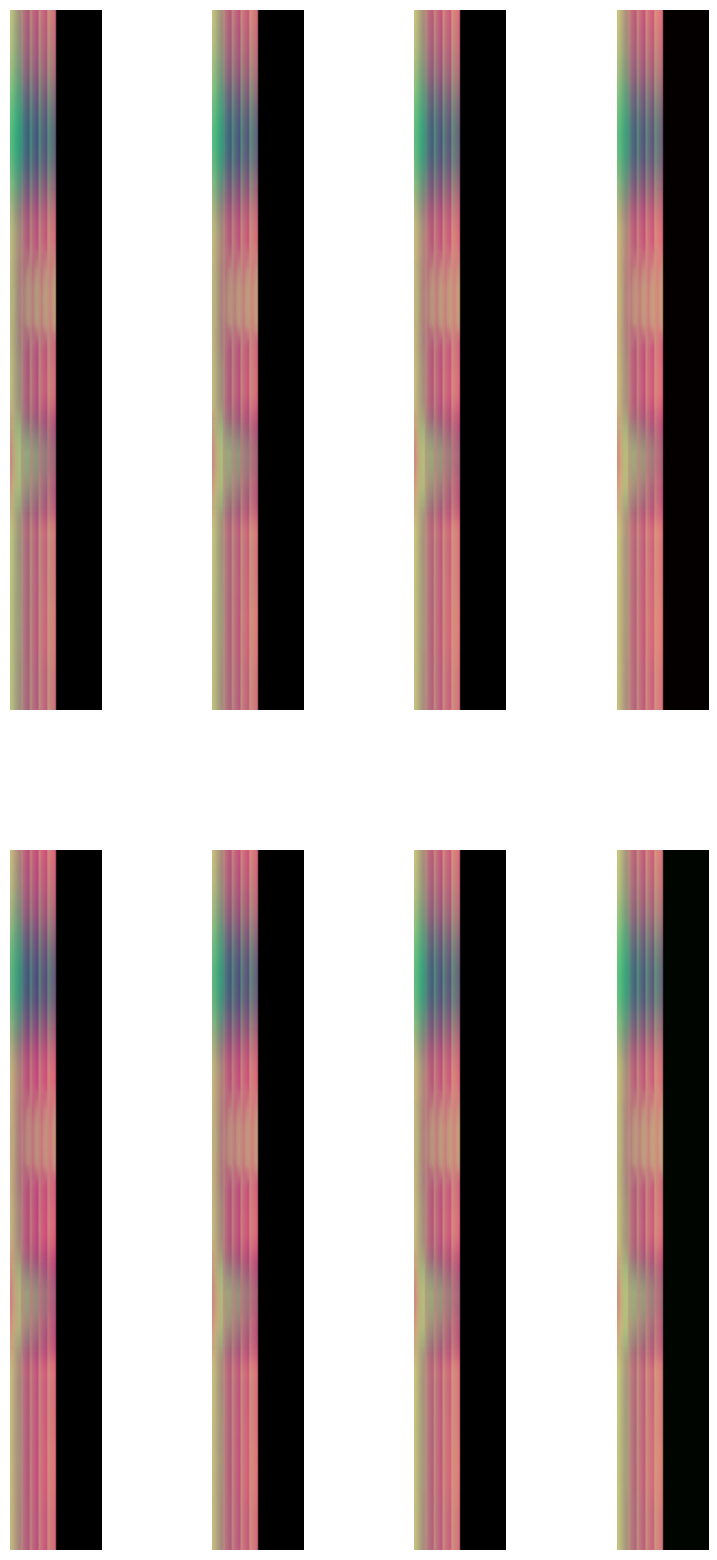

In [21]:
# 4x2 grid of images
plt.figure(figsize=(10, 20))
for i, tmap in enumerate(generatedTmaps):
    plt.subplot(2, 4, i + 1)
    plt.imshow(restore_blue_channel(tmap, loadedTmapArray))
    plt.axis('off')
# plt.imshow(restore_blue_channel(generatedTmaps[2], loadedTmapArray))

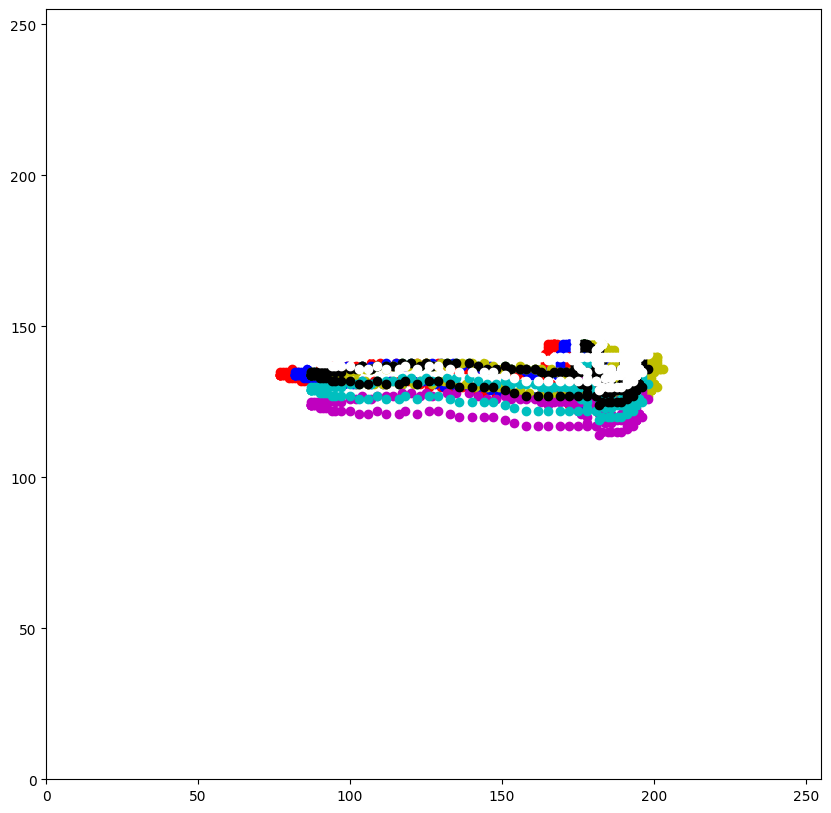

In [45]:
# tmap = generatedTmaps[0]
colors = ['ro', 'bo', 'go', 'yo', 'mo', 'co', 'ko', 'wo']  # List of colors for different tmaps

plt.figure(figsize=(10, 10))
for idx, tmap in enumerate(generatedTmaps):
    color = colors[idx % len(colors)]  # Cycle through colors
    for frame in tmap:
        # Plot the motion of point 9 with a line connecting each point
        plt.plot(frame[9][0], frame[9][1], color)
        
        plt.xlim(0, 255)
        plt.ylim(0, 255)
plt.show()
